# Retinal Vessel Segmentation using PyTorch and U-Net

This notebook implements a deep learning pipeline using the **U-Net** architecture to segment blood vessels in retinal fundus images. Blood vessel segmentation is a crucial task in medical imaging, helping in the diagnosis and monitoring of ophthalmological and cardiovascular diseases (like diabetic retinopathy, glaucoma, and hypertension).

### Dataset Description
We use the retinal fundus images provided in the `data/` directory:
- **Original Images**: `data/original/*.ppm` (700x605 RGB fundus images)
- **Gold Standard Labels**: `data/labels/*.vk.ppm` (700x605 grayscale binary masks where white pixels indicate blood vessels)

### Pipeline Overview
1. **Preprocessing & Augmentation**: Resize images to 512x512, normalize, and apply matching random horizontal/vertical flips and rotations to prevent overfitting on the small dataset (20 images).
2. **U-Net Model**: A custom PyTorch U-Net architecture containing an encoder, bottleneck, decoder, and skip-connections.
3. **Loss Function**: A combined Loss of **Binary Cross Entropy (BCE)** and **Dice Loss** to address the class imbalance (vessels represent only ~10% of pixels).
4. **Training**: Train the model with the Adam optimizer and a learning rate scheduler.
5. **Evaluation**: Compute Accuracy, F1-score (Dice), Jaccard Index (IoU), Sensitivity, and Specificity.
6. **Visualization**: Plot loss curves and compare model predictions side-by-side with ground truth masks.

## 1. Imports and Device Configuration

Let's import the required libraries and check if an NVIDIA GPU is available for acceleration. If the GPU memory is heavily occupied by other processes, we fall back to CPU with a lighter network size to prevent Out Of Memory (OOM) crashes.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

from sklearn.metrics import accuracy_score, f1_score, jaccard_score, confusion_matrix

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device setup and resource management
use_cuda = torch.cuda.is_available()
features = [64, 128, 256, 512]
num_epochs = 40

if use_cuda:
    try:
        # Check free memory
        free_mem = torch.cuda.mem_get_info()[0] / (1024**3) # in GB
        if free_mem < 1.0:
            print(f"CUDA is available but only {free_mem:.2f} GB free VRAM. Falling back to CPU to avoid OOM.")
            use_cuda = False
        else:
            # Test allocation
            x_test = torch.zeros((1, 3, 512, 512), device="cuda")
            del x_test
            torch.cuda.empty_cache()
    except Exception as e:
        print(f"CUDA is available but testing allocation failed: {e}. Falling back to CPU.")
        use_cuda = False

device = torch.device("cuda" if use_cuda else "cpu")
print(f"Using device: {device}")

if device.type == "cpu":
    print("Using a lighter U-Net architecture and fewer epochs for faster CPU execution.")
    features = [32, 64, 128, 256]
    num_epochs = 20
else:
    print("GPU Model:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Model: NVIDIA GeForce RTX 4090


## 2. Dataset and Augmentation

Since deep learning models need consistent shapes, we resize the inputs to $512 \times 512$ pixels. To prevent overfitting on this small 20-image dataset, we use data augmentation. 

We implement a custom `Dataset` class. To ensure that the **same** random geometric transforms (flips, rotations) are applied to both the input image and its label mask, we use PyTorch's functional transforms.

In [2]:
class RetinalDataset(Dataset):
    def __init__(self, image_dir, label_dir, image_ids, transform=False, target_size=(512, 512)):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.image_ids = image_ids
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = self.image_dir / f"{img_id}.ppm"
        lbl_path = self.label_dir / f"{img_id}.vk.ppm"

        # Load image and label
        image = Image.open(img_path).convert("RGB")
        label = Image.open(lbl_path).convert("L")

        # Resize
        image = TF.resize(image, self.target_size)
        label = TF.resize(label, self.target_size, interpolation=TF.InterpolationMode.NEAREST)

        # Apply joint augmentations if training
        if self.transform:
            # Random horizontal flipping
            if random.random() > 0.5:
                image = TF.hflip(image)
                label = TF.hflip(label)

            # Random vertical flipping
            if random.random() > 0.5:
                image = TF.vflip(image)
                label = TF.vflip(label)

            # Random rotation
            if random.random() > 0.5:
                angle = random.randint(-30, 30)
                image = TF.rotate(image, angle)
                label = TF.rotate(label, angle)

        # Convert to tensor
        image = TF.to_tensor(image)  # converts to [0.0, 1.0]
        label = TF.to_tensor(label)  # converts to [0.0, 1.0]

        # Binarize label to ensure strictly 0 and 1
        label = (label > 0.5).float()

        return image, label

### Train / Validation Split

We list the available image IDs and split them: 15 images for training and 5 for validation.

In [3]:
DATA_DIR = Path("data")
ORIGINAL_DIR = DATA_DIR / "original"
LABELS_DIR = DATA_DIR / "labels"

# Find and sort all image IDs
all_image_ids = sorted([p.stem for p in ORIGINAL_DIR.glob("*.ppm")])
print(f"Found {len(all_image_ids)} images in total.")

# Perform split (15 train, 5 validation)
train_ids = all_image_ids[:15]
val_ids = all_image_ids[15:]

print("Train IDs:", train_ids)
print("Validation IDs:", val_ids)

# Create Datasets
train_dataset = RetinalDataset(ORIGINAL_DIR, LABELS_DIR, train_ids, transform=True)
val_dataset = RetinalDataset(ORIGINAL_DIR, LABELS_DIR, val_ids, transform=False)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2)

Found 20 images in total.
Train IDs: ['im0001', 'im0002', 'im0003', 'im0004', 'im0005', 'im0044', 'im0077', 'im0081', 'im0082', 'im0139', 'im0162', 'im0163', 'im0235', 'im0236', 'im0239']
Validation IDs: ['im0240', 'im0255', 'im0291', 'im0319', 'im0324']


## 3. U-Net Model Architecture

U-Net consists of an **Encoder** (downsampling path to capture context), a **Bottleneck**, a **Decoder** (upsampling path to enable precise localization), and **Skip Connections** that concatenate feature maps from the encoder to the decoder to preserve high-frequency details (like thin vessels).

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down part of UNet
        curr_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(curr_in, feature))
            curr_in = feature

        # Up part of UNet
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])
            
            concat_x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_x)

        return self.final_conv(x)

## 4. Loss Function and Evaluation Metrics

Since only ~10% of pixels in the eye fundus belong to vessels, a model optimized solely with Binary Cross Entropy (BCE) might predict background everywhere to get 90% accuracy. To solve this, we combine **BCE** with **Dice Loss**.
Dice Loss directly optimizes the overlap (F1-score) of the positive class.

In [5]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        # Apply sigmoid to convert logits to probabilities
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)
        
        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1.0 - dice

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, preds, targets):
        return self.bce_weight * self.bce(preds, targets) + self.dice_weight * self.dice(preds, targets)

## 5. Training Pipeline

We define the training and validation loops, and run training using the Adam optimizer and the parameters set in Section 1.

In [6]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * images.size(0)
    return epoch_loss / len(loader.dataset)

def validate_epoch(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0
    all_preds = []
    all_masks = []
    
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            epoch_loss += loss.item() * images.size(0)
            
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.append(preds.cpu())
            all_masks.append(masks.cpu())
            
    all_preds = torch.cat(all_preds, dim=0).numpy().ravel()
    all_masks = torch.cat(all_masks, dim=0).numpy().ravel()
    
    acc = accuracy_score(all_masks, all_preds)
    f1 = f1_score(all_masks, all_preds, zero_division=0)
    iou = jaccard_score(all_masks, all_preds, zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(all_masks, all_preds).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    return {
        "loss": epoch_loss / len(loader.dataset),
        "accuracy": acc,
        "f1": f1,
        "iou": iou,
        "sensitivity": sensitivity,
        "specificity": specificity
    }

In [7]:
model = UNet(in_channels=3, out_channels=1, features=features).to(device)
criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_iou": [],
    "val_sensitivity": [],
    "val_specificity": []
}

best_val_iou = 0.0
checkpoint_path = "best_unet.pth"

print(f"Starting U-Net Training for {num_epochs} epochs...")
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = validate_epoch(model, val_loader, criterion, device)
    
    # Adjust learning rate
    scheduler.step(val_metrics["loss"])
    
    # Record history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_sensitivity"].append(val_metrics["sensitivity"])
    history["val_specificity"].append(val_metrics["specificity"])
    
    # Save best checkpoint
    if val_metrics["iou"] > best_val_iou:
        best_val_iou = val_metrics["iou"]
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Epoch {epoch:02d}: New best Val IoU = {best_val_iou:.4f}! Model saved.")
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | Val IoU: {val_metrics['iou']:.4f} | Val F1: {val_metrics['f1']:.4f}")

Starting U-Net Training for 40 epochs...


Epoch 01: New best Val IoU = 0.1021! Model saved.
Epoch 01/40 | Train Loss: 0.6818 | Val Loss: 2.9140 | Val IoU: 0.1021 | Val F1: 0.1852
Epoch 03: New best Val IoU = 0.1450! Model saved.
Epoch 05: New best Val IoU = 0.2528! Model saved.
Epoch 05/40 | Train Loss: 0.4298 | Val Loss: 0.5301 | Val IoU: 0.2528 | Val F1: 0.4036
Epoch 08: New best Val IoU = 0.2747! Model saved.
Epoch 09: New best Val IoU = 0.3625! Model saved.
Epoch 10: New best Val IoU = 0.3794! Model saved.
Epoch 10/40 | Train Loss: 0.3235 | Val Loss: 0.4268 | Val IoU: 0.3794 | Val F1: 0.5500
Epoch 15/40 | Train Loss: 0.2730 | Val Loss: 0.4017 | Val IoU: 0.3760 | Val F1: 0.5465
Epoch 16: New best Val IoU = 0.3959! Model saved.
Epoch 20: New best Val IoU = 0.4497! Model saved.
Epoch 20/40 | Train Loss: 0.2428 | Val Loss: 0.3529 | Val IoU: 0.4497 | Val F1: 0.6204
Epoch 24: New best Val IoU = 0.4851! Model saved.
Epoch 25/40 | Train Loss: 0.2248 | Val Loss: 0.3574 | Val IoU: 0.4401 | Val F1: 0.6112
Epoch 30/40 | Train Loss: 0.

## 6. Training Curve Visualizations

We load the best saved model state and plot the train/validation loss curves alongside key segmentation metrics.

Loaded best model checkpoint.


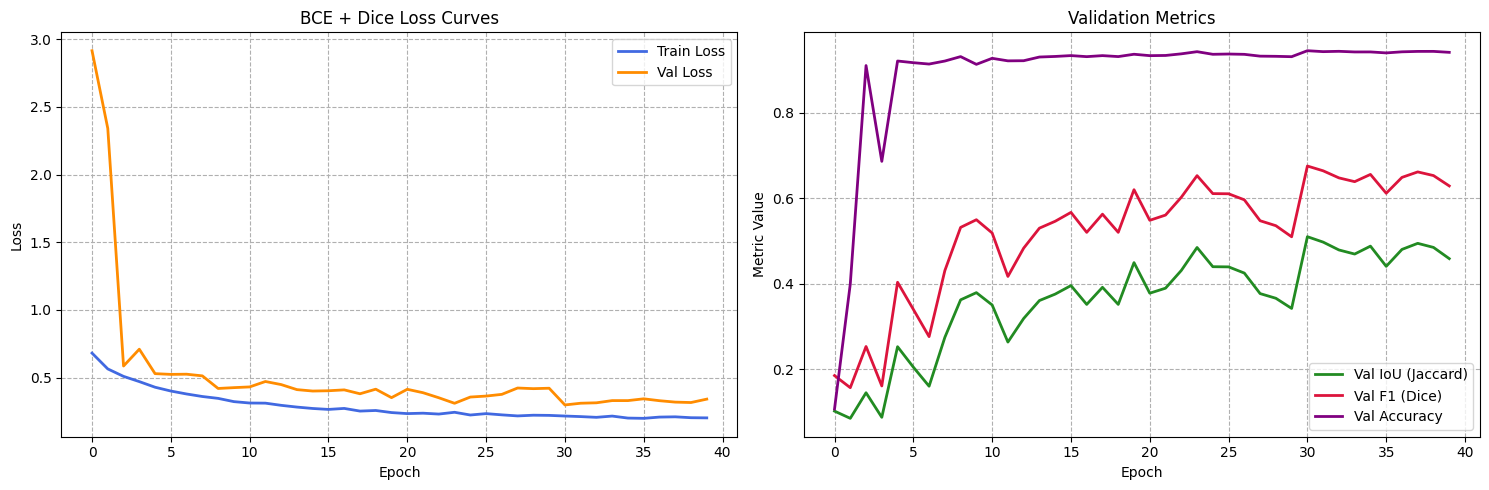

In [8]:
# Load best weights
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path))
    print("Loaded best model checkpoint.")

# Plot loss curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", color="royalblue", lw=2)
plt.plot(history["val_loss"], label="Val Loss", color="darkorange", lw=2)
plt.title("BCE + Dice Loss Curves", fontsize=12)
plt.xlabel("Epoch", fontsize=10)
plt.ylabel("Loss", fontsize=10)
plt.grid(True, ls="--")
plt.legend()

# Plot validation metrics
plt.subplot(1, 2, 2)
plt.plot(history["val_iou"], label="Val IoU (Jaccard)", color="forestgreen", lw=2)
plt.plot(history["val_f1"], label="Val F1 (Dice)", color="crimson", lw=2)
plt.plot(history["val_acc"], label="Val Accuracy", color="purple", lw=2)
plt.title("Validation Metrics", fontsize=12)
plt.xlabel("Epoch", fontsize=10)
plt.ylabel("Metric Value", fontsize=10)
plt.grid(True, ls="--")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Sample Predictions Visualization

Finally, let's run predictions on the validation set using our trained U-Net and visualize the results. We will show:
1. The Original RGB Image
2. The Ground Truth Mask
3. The U-Net Predicted Probability Map (raw Sigmoid outputs)
4. The Final Binarized Segmentation Mask (probability > 0.5)

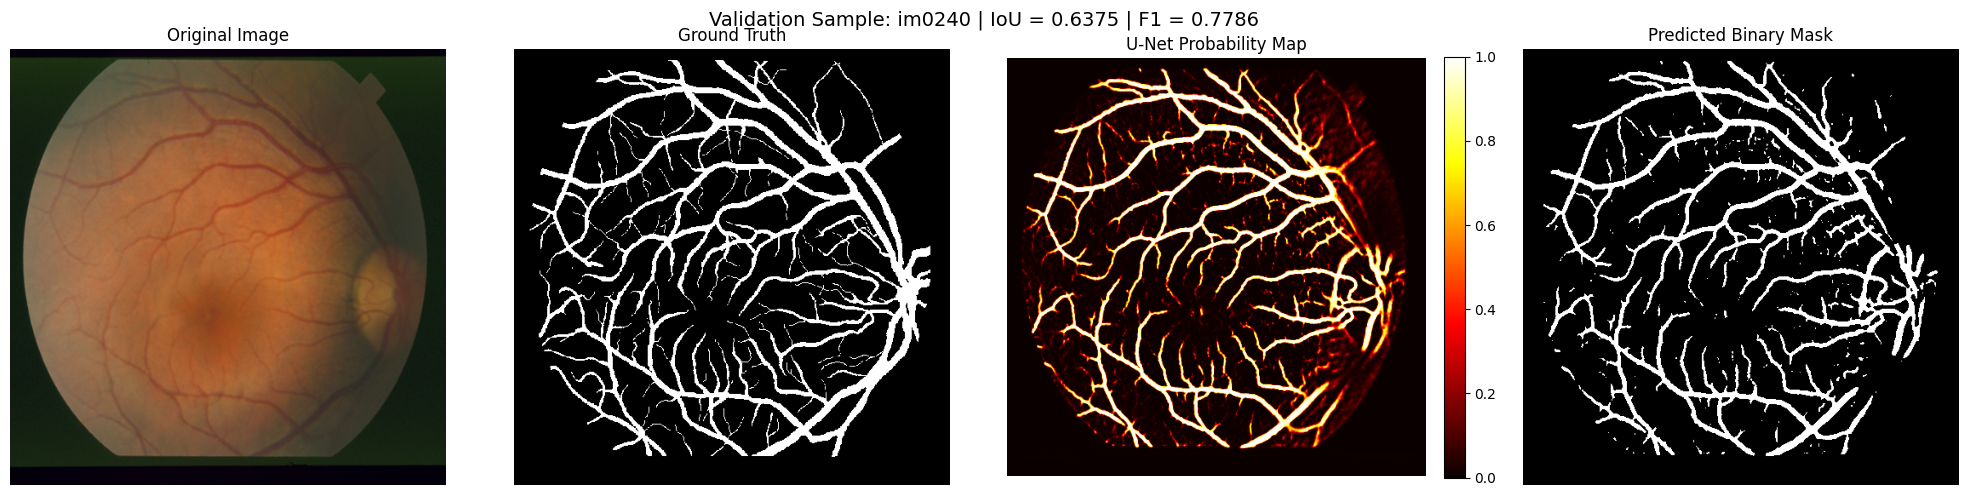

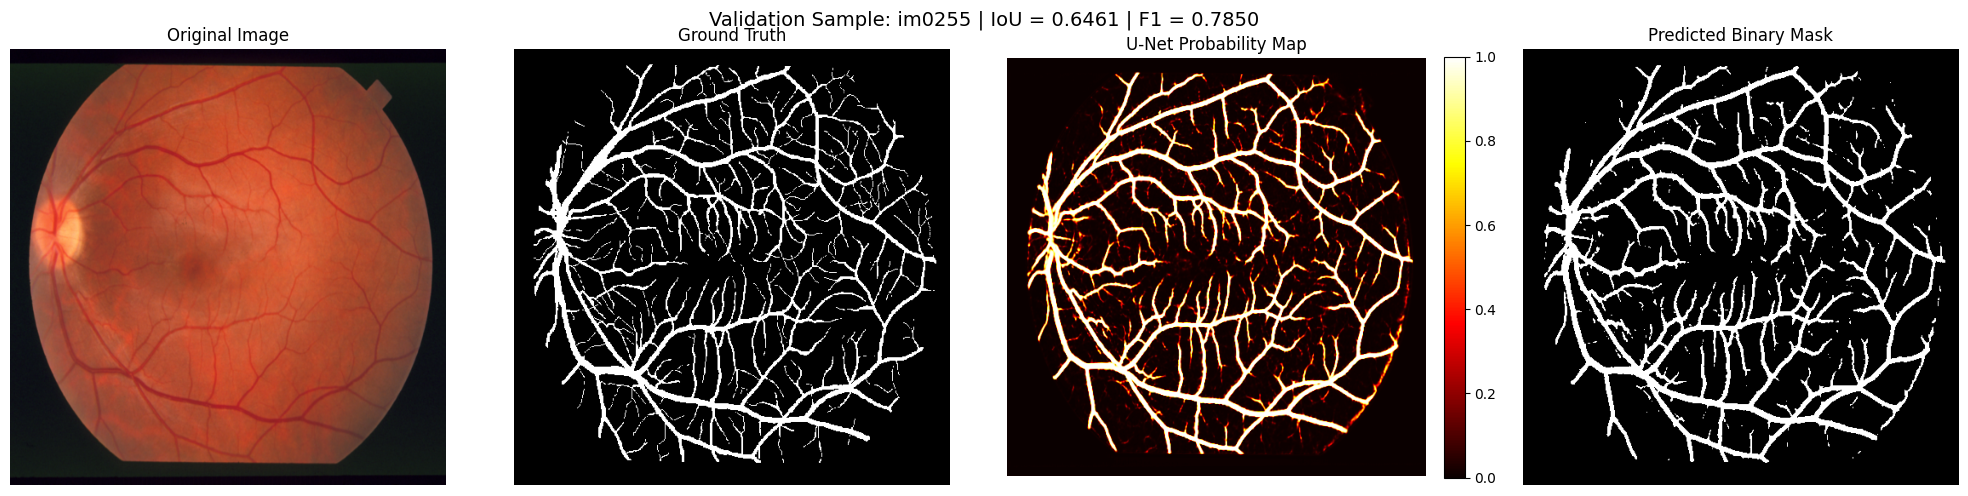

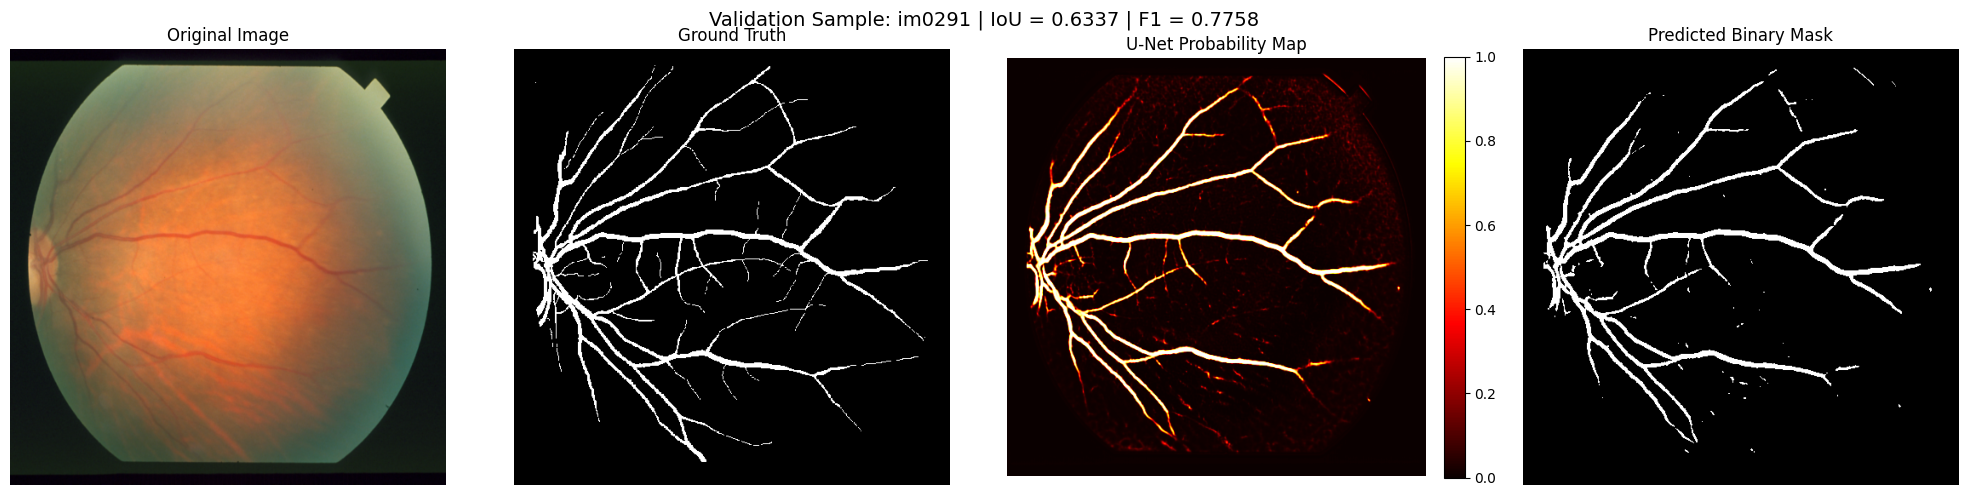

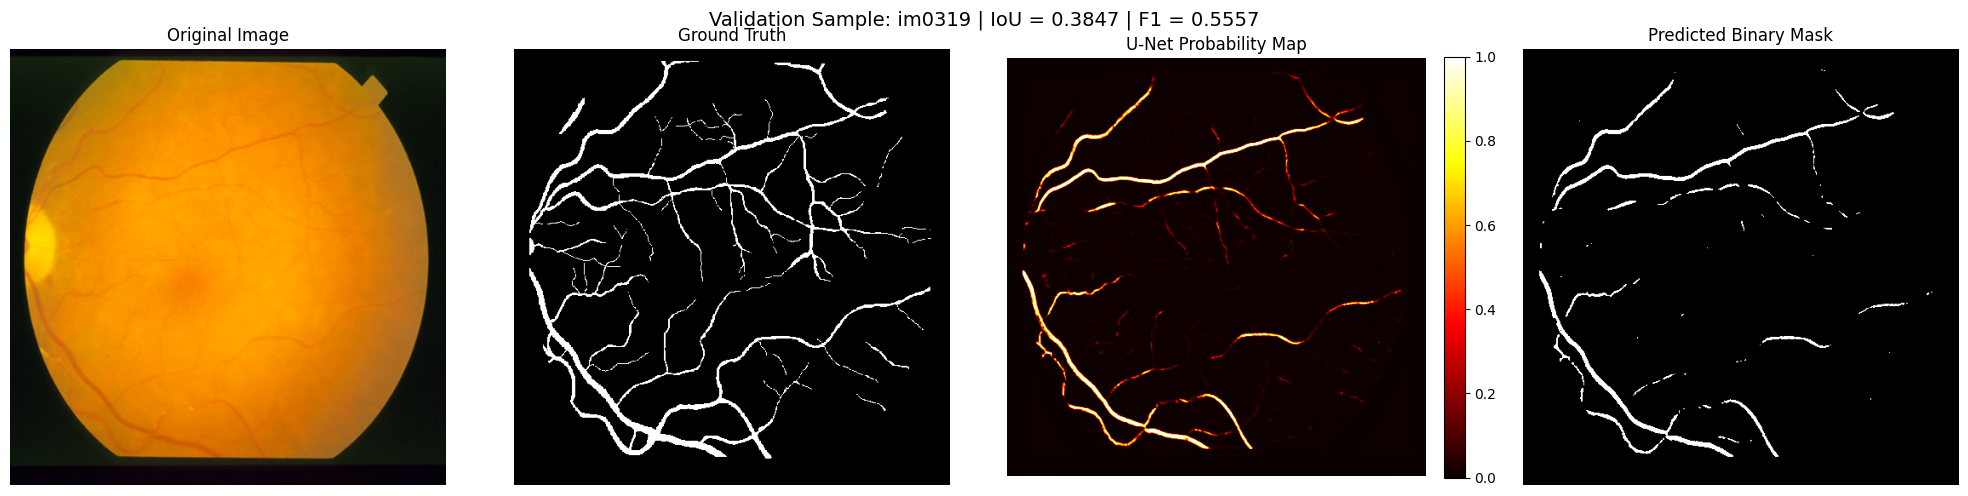

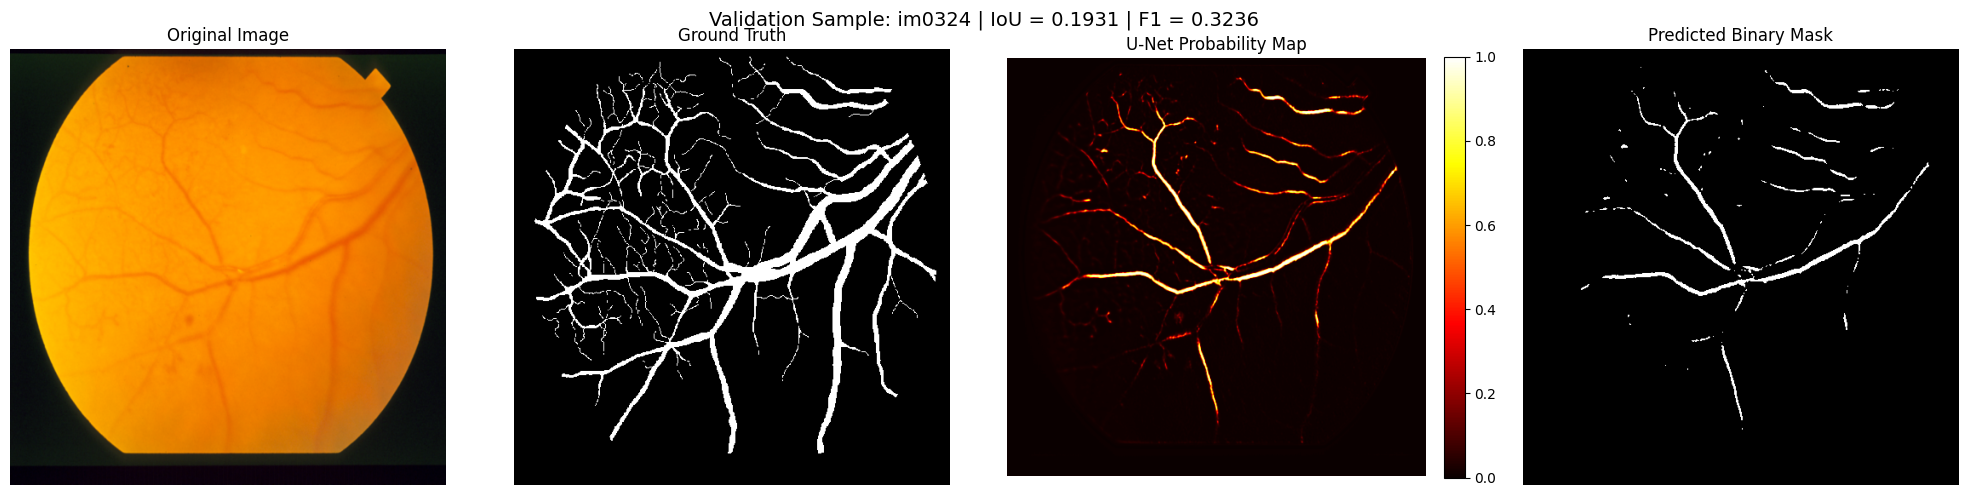

In [ ]:
model.eval()
with torch.no_grad():
    for i in range(len(val_dataset)):
        img, mask = val_dataset[i]
        img_id = val_ids[i]
        
        # Add batch dimension and send to device
        img_tensor = img.unsqueeze(0).to(device)
        outputs = model(img_tensor)
        prob_map = torch.sigmoid(outputs).squeeze(0).squeeze(0).cpu().numpy()
        pred_mask = (prob_map > 0.2).astype(np.uint8)
        
        img_np = img.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze(0).numpy()
        
        # Compute single image metrics
        flat_mask = mask_np.ravel()
        flat_pred = pred_mask.ravel()
        iou = jaccard_score(flat_mask, flat_pred, zero_division=0)
        f1 = f1_score(flat_mask, flat_pred, zero_division=0)
        
        # Visualize
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(f"Validation Sample: {img_id} | IoU = {iou:.4f} | F1 = {f1:.4f}", fontsize=14)
        
        axes[0].imshow(img_np)
        axes[0].set_title("Original Image")
        axes[0].axis("off")
        
        axes[1].imshow(mask_np, cmap="gray")
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")
        
        pos = axes[2].imshow(prob_map, cmap="hot", vmin=0, vmax=1)
        axes[2].set_title("U-Net Probability Map")
        axes[2].axis("off")
        fig.colorbar(pos, ax=axes[2], fraction=0.046, pad=0.04)
        
        axes[3].imshow(pred_mask, cmap="gray")
        axes[3].set_title("Predicted Binary Mask")
        axes[3].axis("off")
        
        plt.tight_layout()
        plt.show()